# 19a — Does Gaussian (Voigt) broadening explain the real-data attractor?

**Series 19 — autonomous improvement round (goal: honest uncertainties on the real dataset).**
Trial a: closed-loop synthetic sweep over Gaussian broadening σ_G, with the current 18c
optimizer (pure-Lorentzian simulator) kept EXACTLY as-is.

**Key insight:** <TBD — filled after the run>

## 1. CURRENT STATE ANALYSIS (written before this trial)

### 1.1 The goal (restated, Anuar 2026-08-30)
The model must produce **honest uncertainties**: well-identified parameters → tight and
accurate; poorly-identified parameters → wide but with the truth inside. A point estimate
that misses is ACCEPTABLE as long as it lies within the reported uncertainty. **Tight and
wrong is the failure.** (This is the paper's core message: the median is "precise but
inaccurate"; Monte Carlo reconstruction gives honest intervals.)

### 1.2 The pipeline (as it stands)
generate → fit → compare → update, all differentiable:
- **Generator**: n ~ round(max(μ + σ_prop·ε, 0)) photons from a **pure Cauchy (Lorentzian)**
  line at scale γ, truncated to ±75 MHz; m ~ Poisson(λ) uniform background detunings.
- **Fit** (per scan): unbinned Lorentzian MLE (L-BFGS), width = sigmoid map, FWHM = 2γ;
  implicit differentiation (IFT) gives dFWHM/dγ, dσ/dγ and the CRLB per-scan fit σ.
- **Likelihood**: 2D KDE over (FWHM, σ_fit), Scott bandwidths (H_F from FWHM, H_S floored at h_s_min).
- **Optimizer** (18c state): μ via REINFORCE with σ_ref=10 self-normalized score; γ via KDE
  gradient in **z-form** (dlogG = (d_f·∂F/∂γ/H_F + d_s·∂σ/∂γ/H_S)/H_REF, H_REF=1) — the 17g fix;
  γ anneal 0.5, CLIP=10, λ_mean=0, μ ∈ [1,200], γ ∈ [0.1,100], deterministic seeds
  (SEED=42 per step, SYNTH_SEED=12345 targets).

### 1.3 What the series told us
- **13-series (real data)**: mean FWHM matched (92–96%), but the **spread was stuck at
  ~40–50% of target** (std ~4–5 vs 10.2) regardless of hyperparameters → "model gap,
  not hyperparameters" (JOURNAL 12.08). μ weakly identified.
- **17-series (synthetic, pure Lorentzian)**: with the z-form γ-score (17g) the optimizer
  recovers BOTH parameters almost perfectly (μ RMSE 1.13, γ RMSE 0.59; rel 3.7%/4.3%).
  So on self-consistent data the machinery is excellent.
- **18-series (real data)**: μ lands at **~½ of reference** everywhere, but within huge σ_μ
  (0.02–1.7σ — flat μ likelihood: HONEST but low-information). γ: 3nW high-T good
  (12.1–14.3 vs 14.1); **1nW γ systematically low** (T20 5.54, T60 7.06 vs 8.5, ~2σ with
  moderately tight σ); 3nW low-T under-shoots (T05 5.59 at −8.5σ, T10 8.31 at −5.8σ);
  over-confident basins seen in 18b (1nW T10 −8.3σ tight; 3nW T10 σ≈0 at γ̂ 31.97).
- **Failure modes #6/#7 (context.md)**: #6 Voigt-vs-Lorentzian **spread gap** — real scans
  are fitted with Voigt profiles (Gaussian broadening from spectral diffusion), our
  simulator emits a pure Lorentzian and cannot produce the observed spread. #7 real-data
  μ attractor at ~½ reference — explanation (a): the real likelihood genuinely prefers
  lower μ because the model can only fake a wider FWHM cloud by lowering μ (fewer photons
  → worse fits → broader spread).

### 1.4 The unifying hypothesis (this trial)
**Both symptoms are one mechanism.** The real line carries Gaussian broadening σ_G
(spectral diffusion). Consequences:
1. **Low-γ offset**: the reference γ_true = median FWHM(Trans100)/2 is a **Voigt** FWHM
   (= F(γ_L, σ_G)/2 > γ_L). The model's γ is the **Cauchy** HWHM γ_L. An optimizer that
   correctly recovers γ_L will look systematically low against the reference, and the
   offset grows with σ_G/γ — larger relative effect at 1nW (γ=8.5) than 3nW (γ=14.1),
   exactly the observed pattern.
2. **Half-μ attractor**: a Lorentzian-only simulator cannot reproduce the data's spread at
   (μ_true, γ_L); the only way to widen the simulated FWHM cloud is to lower μ (photon
   starvation). The likelihood attractor therefore sits at low μ — but with a FLAT μ
   direction (weak identifiability) so the Fisher σ_μ is huge and the truth stays inside
   (honest but useless).
3. **The dangerous cases** are where the misfit DOESN'T flatten the likelihood: sharp
   wrong basins (18b 1nW T10, 3nW T10) where σ is tight and the truth is OUTSIDE —
   dishonest uncertainty. We need to know when/why that happens.

### 1.5 Why this trial is the right next step
JOURNAL 12.08 already flagged the pseudo-Voigt simulator change as "the more consequential
thing to check first" and "a prerequisite for the final real-data fine-tuning" — it was
never tested. Before changing the model (19b), we quantify the disease in closed loop:
**generate Voigt data at known (μ_true, γ_L), recover with the current Lorentzian-only
optimizer, and measure both the point bias AND the honesty of the Fisher uncertainty as a
function of σ_G.** This also gives us a calibrated σ_G for the real data (match the spread
gap) for 19b.

## 2. PROPOSAL — closed-loop Voigt sweep (design, predictions, decision rule)

### 2.1 Design
- **Data**: synthetic targets generated from a **Voigt line**: Cauchy detunings at
  γ_true + Gaussian offset N(0, σ_G), window-truncated (out-of-window photons lost),
  background as usual; fitted with the SAME Lorentzian MLE as the real pipeline
  (this mimics the real setup: Voigt-physics data, Lorentzian estimator).
- **Optimizer**: 18c config EXACTLY (z-form γ-score, σ_ref μ-score, anneal, clip, seeds).
  No changes anywhere on the simulator/optimizer side — targets are the only difference.
- **Sweep**: σ_G ∈ {0, 2, 4, 6, 8} MHz × 6 experiments
  (1nW T20/T60/T100 + 3nW T20/T60/T100) = 30 runs. σ_G=0 is the control (pure Lorentzian
  → should reproduce 17g-quality recovery; validates the machinery).
- **Uncertainty**: Fisher/CRB at the fitted point (15-series protocol: M_FINAL sims,
  raw γ-score for comparability), plus the 13-series **spread diagnostic**
  (simulated FWHM std vs target FWHM std at the fitted point).
- **Cheap pre-screen first** (PRE_SCREEN=True: 40×40, σ_G ∈ {0,4,8}, 2 exps, capped
  targets) to validate machinery and direction before the full ~3.5h run.

### 2.2 Predictions
- **Control (σ_G=0)**: near-perfect recovery (μ̂≈μ_true, γ̂≈γ_L), |Δ|/σ ≲ 1 everywhere.
- **As σ_G grows**:
  - μ̂/μ_true drops toward ~½ — reproducing the real-data attractor;
  - γ̂ vs the Voigt reference F(γ_L,σ_G)/2 looks systematically low (while γ̂ vs γ_L
    itself may stay close) — reproducing the 1nW pattern;
  - spread ratio (sim std / target std) < 1 and falling — the model cannot keep up;
  - the interesting question: does the Fisher σ stay HONEST (wide, truth inside) or does
    some (σ_G, exp) region develop tight-wrong basins (|Δ|/σ > 2 with small σ)?

### 2.3 Decision rule → 19b
- If the sweep reproduces the real-data pattern (half-μ, low-γ vs reference, spread gap,
  and/or tight-wrong basins) → **19b implements the pseudo-Voigt simulator** (additive
  `draw_fixed_noise_voigt` in src/samplers.py; src already has pseudo-Voigt fitting +
  Olivero-Longbothum FWHM), calibrates σ_G per power from the real Trans100 spread, and
  validates on real data (14 exps, full Fisher).
- If NOT (e.g., μ stays recovered, γ honest) → the Voigt hypothesis dies cleanly and 19b
  attacks μ identifiability directly (likelihood/score design).
- Either way: the sweep gives a **coverage map** telling us where uncertainty is honest.

In [3]:
# ============================================================
# 3. CONFIG + BENCHMARK (series 19, trial a)
# ============================================================
import math, time, os, sys, json, warnings
warnings.filterwarnings('ignore')   # torch copy-construct warnings from src/samplers.py
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, sample_cauchy_truncated, FREQ_MIN, FREQ_MAX
from src.implicit import compute_fwhm_and_dgamma

# ---- run mode: SMOKE > PRE_SCREEN > FULL (env vars set by the driver) ----
SMOKE = os.environ.get('S19_SMOKE', '0') == '1'
PRE_SCREEN = os.environ.get('S19_PRESCREEN', '0') == '1'
if SMOKE:
    SWEEP_SIGMAS = [4.0]
    SWEEP_EXPS = ['1nW Trans60']
    N_RUNS, N_ITER = 6, 5
    TARGET_CAP, M_FINAL = 40, 50
elif PRE_SCREEN:
    SWEEP_SIGMAS = [0.0, 4.0, 8.0]
    SWEEP_EXPS = ['1nW Trans60', '3nW Trans60']
    N_RUNS, N_ITER = 40, 40
    TARGET_CAP, M_FINAL = 400, 100
else:
    SWEEP_SIGMAS = [0.0, 2.0, 4.0, 6.0, 8.0]
    SWEEP_EXPS = ['1nW Trans20', '1nW Trans60', '1nW Trans100',
                  '3nW Trans20', '3nW Trans60', '3nW Trans100']
    N_RUNS, N_ITER = 100, 100
    TARGET_CAP, M_FINAL = None, 200

# ---- fixed optimizer protocol (18c EXACTLY) ----
LR_MU, LR_GAMMA = 15.0, 0.5
SIGMA_REF, CLIP = 10.0, 10.0
GAMMA_ANNEAL, H_S_MIN = 0.5, 0.05
H_REF, LAMBDA_MEAN = 1.0, 0.0
SEED, SYNTH_SEED = 42, 12345
FISHER_BASE_SEED = 7000

EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]
EXPERIMENTS = [e for e in EXPERIMENTS if e['name'] in SWEEP_EXPS]
print(f'mode: {"SMOKE" if SMOKE else ("PRE_SCREEN" if PRE_SCREEN else "FULL")} | '
      f'{len(EXPERIMENTS)} exps x {len(SWEEP_SIGMAS)} sigma_G | N_RUNS={N_RUNS} N_ITER={N_ITER} | M_FINAL={M_FINAL}')

mode: FULL | 6 exps x 5 sigma_G | N_RUNS=100 N_ITER=100 | M_FINAL=200


In [4]:
# ============================================================
# 4. VOIGT TARGET GENERATOR (the ONLY change vs 18c — data side)
#    Machinery lives in src/series19.py (module-level = picklable for the pool).
# ============================================================
from src.series19 import voigt_photons, crlb_sigma, scan_features, target_one, target_map

print('Voigt target machinery imported from src/series19')

Voigt target machinery imported from src/series19


In [5]:
# ============================================================
# 5. LIKELIHOOD + FIXED HELPERS (18c machinery; gamma_scale now a parameter)
#    Worker functions (run_one/init_worker/parallel_map) come from src/series19.
# ============================================================
def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, gamma_scale=True):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if gamma_scale:
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w

import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
from src.series19 import run_one, init_worker, parallel_map

N_CPUS = os.cpu_count() or 4
N_WORKERS = 4
print('helpers ready')

helpers ready


In [6]:
# ============================================================
# 6. ONE EXPERIMENT: Voigt targets + 18c optimizer (Lorentzian simulator)
# ============================================================
def run_experiment(exp, sigma_g, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true

    # ---- Voigt targets at TRUE values (deterministic per (exp, sigma_g)) ----
    n_tgt = exp['n_target'] if TARGET_CAP is None else min(exp['n_target'], TARGET_CAP)
    tasks_t = [(exp, sigma_g, i, SYNTH_SEED) for i in range(n_tgt)]
    res_t = target_map(pool, tasks_t)
    target_f = torch.tensor([r[0] for r in res_t], dtype=torch.float32)
    target_s = torch.tensor([r[1] for r in res_t], dtype=torch.float32)
    SCOTT_EXP = n_tgt ** (-1.0 / 6.0)
    H_F = float(target_f.std()) * SCOTT_EXP
    H_S = max(float(target_s.std()) * SCOTT_EXP, H_S_MIN)

    mu_val, gamma_val = float(mu_init), float(gamma_init)
    history = []
    t0 = time.time()
    for step in range(N_ITER):
        rng2 = np.random.default_rng(SEED + step)
        tasks, ns = [], []
        for _ in range(N_RUNS):
            u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
            tasks.append((gamma_val, u.numpy(), b.numpy()))
            ns.append(n)
        res = parallel_map(pool, tasks)
        ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
        si_t = torch.tensor([r[1] for r in res], dtype=torch.float32)
        nt = torch.tensor(ns, dtype=torch.float32)
        dg_t = torch.tensor([r[2] for r in res], dtype=torch.float32)
        ds_t = torch.tensor([r[3] for r in res], dtype=torch.float32)

        s_mu, s_gamma, nll_val, w = kde_scores(
            ft, si_t, nt, dg_t, ds_t, target_f, target_s, H_F, H_S, mu_val, sigma_prop, gamma_scale=True)

        B = w.mean(dim=0)
        score = (nt - mu_val) / SIGMA_REF ** 2
        grad_mu = float(max(min(-(B - B.mean()) @ score, CLIP), -CLIP))
        grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))

        lr_mu_decay = LR_MU * (1.0 - step / N_ITER)
        mu_val -= lr_mu_decay * grad_mu
        mu_val = max(1.0, min(200.0, mu_val))
        gamma_val -= LR_GAMMA * (1.0 - GAMMA_ANNEAL * step / N_ITER) * grad_gamma
        gamma_val = max(0.1, min(100.0, gamma_val))
        history.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val)))

    return dict(exp=exp['name'], power=exp['power'], sigma_g=sigma_g,
                mu_true=mu_true, gamma_true=gamma_true,
                sigma_prop=sigma_prop, lam=lam, n_target=n_tgt,
                mu_final=mu_val, gamma_final=gamma_val,
                nll_final=history[-1]['nll'], history=history,
                target_f=target_f, target_s=target_s, H_F=H_F, H_S=H_S,
                t_elapsed=time.time() - t0)

print('run_experiment ready (Voigt targets, Lorentzian simulator)')

run_experiment ready (Voigt targets, Lorentzian simulator)


In [7]:
# ============================================================
# 7. FISHER / CRB at the fitted point (15-series protocol; raw γ-score)
#    + the 13-series spread diagnostic (sim std / target std)
# ============================================================
def fisher_at_fitted(r, pool):
    mu_f, gamma_f = r['mu_final'], r['gamma_final']
    sp, lam = r['sigma_prop'], r['lam']
    rng = np.random.default_rng(FISHER_BASE_SEED)
    tasks, ns = [], []
    for _ in range(M_FINAL):
        u, b, n = draw_fixed_noise(mu_f, sp, lam, rng)
        tasks.append((gamma_f, u.numpy(), b.numpy()))
        ns.append(n)
    res = parallel_map(pool, tasks)
    ft = torch.tensor([x[0] for x in res], dtype=torch.float32)
    si_t = torch.tensor([x[1] for x in res], dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor([x[2] for x in res], dtype=torch.float32)
    ds_t = torch.tensor([x[3] for x in res], dtype=torch.float32)

    s_mu, s_gamma, _, _ = kde_scores(ft, si_t, nt, dg_t, ds_t,
                                     r['target_f'], r['target_s'], r['H_F'], r['H_S'],
                                     mu_f, sp, gamma_scale=False)
    s = torch.stack([s_mu, s_gamma], dim=1)
    J = s.T @ s / len(r['target_f'])
    Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
    std_mu = float(math.sqrt(Jinv[0, 0])); std_gamma = float(math.sqrt(Jinv[1, 1]))
    corr = float(Jinv[0, 1] / torch.sqrt(Jinv[0, 0] * Jinv[1, 1]))
    spread_ratio = float(ft.std()) / float(r['target_f'].std())
    return dict(exp=r['exp'], sigma_g=r['sigma_g'], mu_f=mu_f, gamma_f=gamma_f,
                mu_true=r['mu_true'], gamma_true=r['gamma_true'], n_target=r['n_target'],
                std_mu=std_mu, std_gamma=std_gamma, corr=corr, spread_ratio=spread_ratio,
                dmu_sigma=abs(mu_f - r['mu_true']) / std_mu,
                dgamma_sigma=abs(gamma_f - r['gamma_true']) / std_gamma)

print('fisher_at_fitted ready')

fisher_at_fitted ready


In [8]:
# ============================================================
# 8. RUN THE SWEEP (sigma_G x experiments) — checkpointed
# ============================================================
t_all = time.time()
results, fisher_rows = [], []

def _checkpoint(partial=False):
    rows = [dict(exp=f['exp'], sigma_g=f['sigma_g'], mu_true=f['mu_true'], gamma_true=f['gamma_true'],
                 mu_f=f['mu_f'], gamma_f=f['gamma_f'], std_mu=f['std_mu'], std_gamma=f['std_gamma'],
                 corr=f['corr'], spread_ratio=f['spread_ratio'],
                 dmu_sigma=f['dmu_sigma'], dgamma_sigma=f['dgamma_sigma']) for f in fisher_rows]
    path = '/tmp/19a_sweep_partial.json' if partial else '/tmp/19a_sweep.json'
    json.dump(dict(mode='SMOKE' if SMOKE else ('PRE_SCREEN' if PRE_SCREEN else 'FULL'),
                   sigmas=SWEEP_SIGMAS, exps=SWEEP_EXPS,
                   n_runs=N_RUNS, n_iter=N_ITER, m_final=M_FINAL,
                   rows=rows, done=not partial), open(path, 'w'), indent=1)

try:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=init_worker) as pool:
        for sg in SWEEP_SIGMAS:
            for exp in EXPERIMENTS:
                r = run_experiment(exp, sg, pool)
                f = fisher_at_fitted(r, pool)
                results.append(r); fisher_rows.append(f)
                print(f"sigma_G={sg:>3.0f} {r['exp']:>12}: mu {r['mu_true']:7.2f}->{r['mu_final']:7.2f} "
                      f"(D/s {abs(r['mu_final']-r['mu_true'])/f['std_mu']:4.2f}) | "
                      f"g {r['gamma_true']:5.1f}->{r['gamma_final']:6.2f} "
                      f"(D/s {abs(r['gamma_final']-r['gamma_true'])/f['std_gamma']:4.2f}) | "
                      f"s_mu {f['std_mu']:6.1f} s_g {f['std_gamma']:5.2f} | spread {f['spread_ratio']:.2f} | "
                      f"{r['t_elapsed']/60:.1f} min", flush=True)
                _checkpoint()
except Exception:
    _checkpoint(partial=True)
    raise

with open('/tmp/19a_sweep.json', 'w') as fh:
    json.dump(dict(mode='SMOKE' if SMOKE else ('PRE_SCREEN' if PRE_SCREEN else 'FULL'),
                   sigmas=SWEEP_SIGMAS, exps=SWEEP_EXPS,
                   n_runs=N_RUNS, n_iter=N_ITER, m_final=M_FINAL,
                   rows=fisher_rows), fh, indent=1)
print(f'\\nTotal: {(time.time()-t_all)/60:.1f} min | rows saved to /tmp/19a_sweep.json')


sigma_G=  0  1nW Trans20: mu   17.32->  17.20 (D/s 0.01) | g   8.5->  8.80 (D/s 0.27) | s_mu    8.4 s_g  1.09 | spread 1.08 | 3.0 min
sigma_G=  0  1nW Trans60: mu   61.37->  61.69 (D/s 0.02) | g   8.5->  8.62 (D/s 0.19) | s_mu   17.2 s_g  0.65 | spread 0.90 | 3.2 min
sigma_G=  0 1nW Trans100: mu   70.82->  72.47 (D/s 0.06) | g   8.5->  8.59 (D/s 0.13) | s_mu   26.8 s_g  0.68 | spread 0.94 | 3.2 min
sigma_G=  0  3nW Trans20: mu   34.28->  34.77 (D/s 0.03) | g  14.1-> 14.27 (D/s 0.12) | s_mu   17.0 s_g  1.41 | spread 0.80 | 3.3 min
sigma_G=  0  3nW Trans60: mu  103.20-> 104.22 (D/s 0.03) | g  14.1-> 14.11 (D/s 0.02) | s_mu   31.8 s_g  0.86 | spread 1.07 | 3.3 min
sigma_G=  0 3nW Trans100: mu  175.71-> 178.29 (D/s 0.04) | g  14.1-> 14.24 (D/s 0.16) | s_mu   69.4 s_g  0.89 | spread 0.99 | 3.3 min
sigma_G=  2  1nW Trans20: mu   17.32->  17.18 (D/s 0.02) | g   8.5->  8.86 (D/s 0.29) | s_mu    8.8 s_g  1.27 | spread 0.86 | 3.3 min
sigma_G=  2  1nW Trans60: mu   61.37->  61.48 (D/s 0.01) | g  

figures saved to /tmp/19a_figs
['fig1_bias.png', 'fig2_coverage.png', 'fig3_spread.png', 'fig4_paths.png']


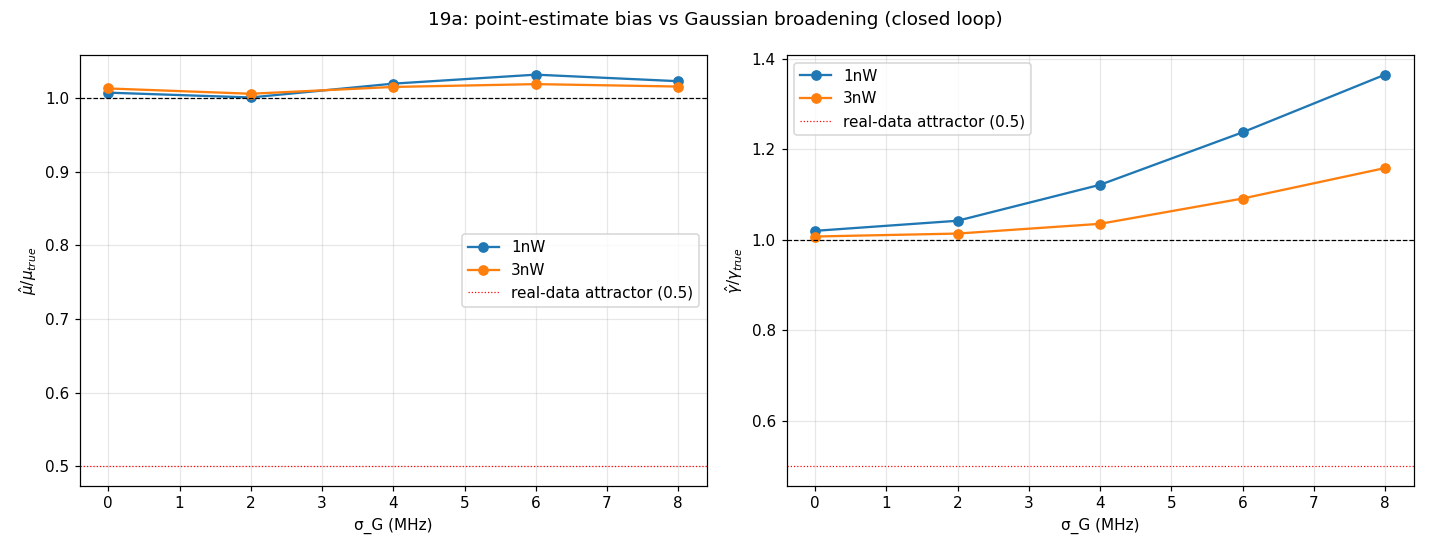

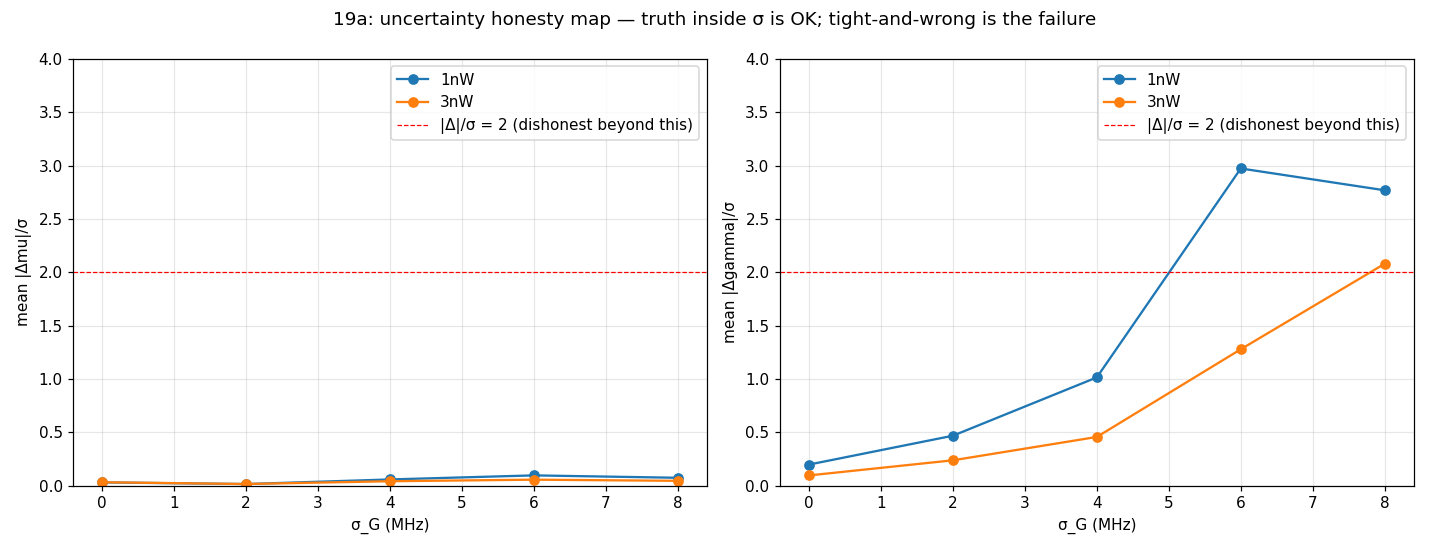

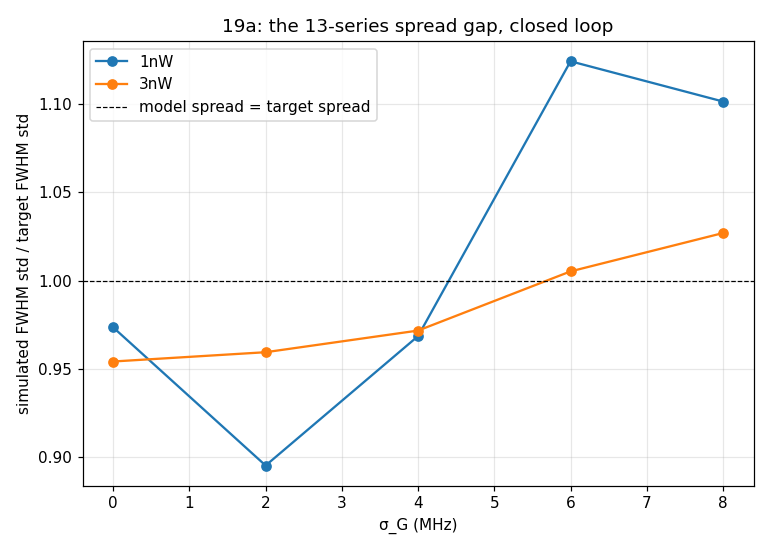

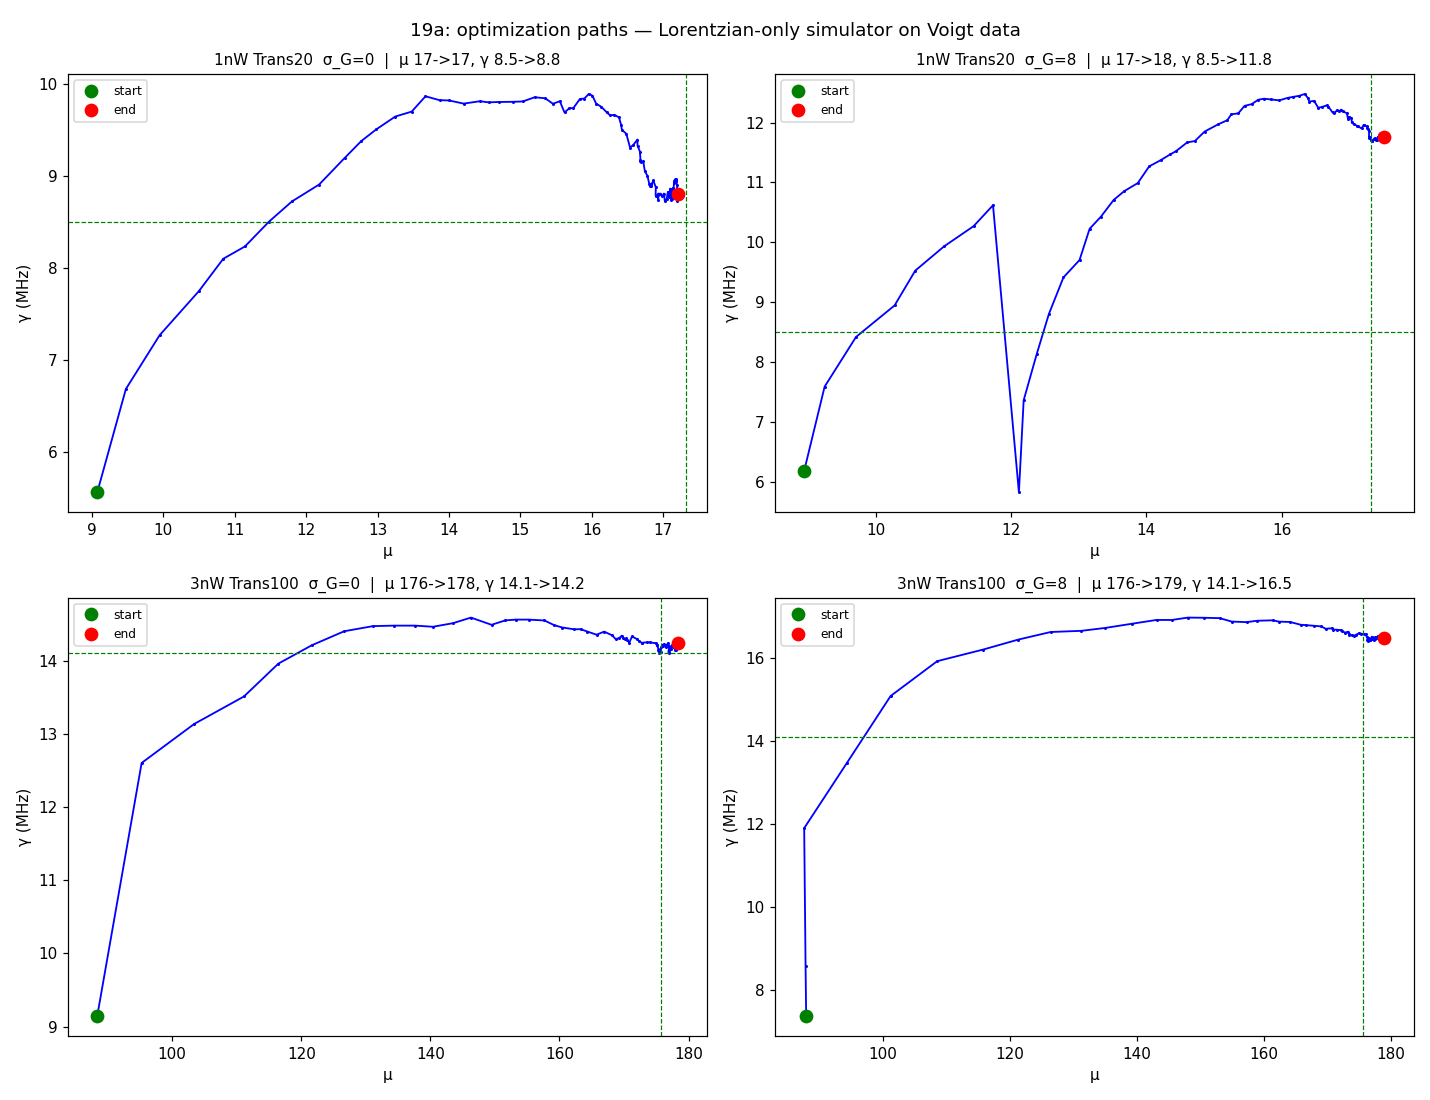

In [9]:
# ============================================================
# 9. FIGURES -> /tmp/19a_figs/
# ============================================================
import os as _os
FIG_DIR = '/tmp/19a_figs'
_os.makedirs(FIG_DIR, exist_ok=True)

# ---- fig 1: point bias vs sigma_G (per power) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, key, ylab in [(axes[0], 'mu', r'$\hat\mu/\mu_{true}$'),
                      (axes[1], 'gamma', r'$\hat\gamma/\gamma_{true}$')]:
    for power in ['1nW', '3nW']:
        xs, ys = [], []
        for sg in SWEEP_SIGMAS:
            rows = [f for f in fisher_rows if f['sigma_g'] == sg and f['exp'].startswith(power)]
            if key == 'mu':
                vals = [f['mu_f'] / f['mu_true'] for f in rows]
            else:
                vals = [f['gamma_f'] / f['gamma_true'] for f in rows]
            xs.append(sg); ys.append(float(np.mean(vals)))
        ax.plot(xs, ys, 'o-', label=power)
    ax.axhline(1.0, color='k', ls='--', lw=0.8)
    ax.axhline(0.5, color='r', ls=':', lw=0.8, label='real-data attractor (0.5)')
    ax.set_xlabel('σ_G (MHz)'); ax.set_ylabel(ylab); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('19a: point-estimate bias vs Gaussian broadening (closed loop)')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig1_bias.png', dpi=110); plt.close(fig)

# ---- fig 2: coverage (|Δ|/σ) vs sigma_G — the honesty map ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, key in [(axes[0], 'mu'), (axes[1], 'gamma')]:
    for power in ['1nW', '3nW']:
        xs, ys = [], []
        for sg in SWEEP_SIGMAS:
            rows = [f for f in fisher_rows if f['sigma_g'] == sg and f['exp'].startswith(power)]
            xs.append(sg); ys.append(float(np.mean([f['dmu_sigma'] if key == 'mu' else f['dgamma_sigma'] for f in rows])))
        ax.plot(xs, ys, 'o-', label=power)
    ax.axhline(2.0, color='r', ls='--', lw=0.8, label='|Δ|/σ = 2 (dishonest beyond this)')
    ax.set_xlabel('σ_G (MHz)'); ax.set_ylabel(f'mean |Δ{key}|/σ'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_ylim(0, max(4.0, ax.get_ylim()[1]))
fig.suptitle('19a: uncertainty honesty map — truth inside σ is OK; tight-and-wrong is the failure')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig2_coverage.png', dpi=110); plt.close(fig)

# ---- fig 3: spread ratio (sim std / target std) vs sigma_G ----
fig, ax = plt.subplots(figsize=(7, 5))
for power in ['1nW', '3nW']:
    xs, ys = [], []
    for sg in SWEEP_SIGMAS:
        rows = [f for f in fisher_rows if f['sigma_g'] == sg and f['exp'].startswith(power)]
        xs.append(sg); ys.append(float(np.mean([f['spread_ratio'] for f in rows])))
    ax.plot(xs, ys, 'o-', label=power)
ax.axhline(1.0, color='k', ls='--', lw=0.8, label='model spread = target spread')
ax.set_xlabel('σ_G (MHz)'); ax.set_ylabel('simulated FWHM std / target FWHM std')
ax.set_title('19a: the 13-series spread gap, closed loop'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig3_spread.png', dpi=110); plt.close(fig)

# ---- fig 4: phase-space paths (first & last exp, first & last sigma_G) ----
exps_run = list(dict.fromkeys(r['exp'] for r in results))
sigs_run = list(dict.fromkeys(r['sigma_g'] for r in results))
picks = sorted({(e, s) for e in (exps_run[0], exps_run[-1]) for s in (sigs_run[0], sigs_run[-1])})
n = len(picks)
fig, axes = plt.subplots(math.ceil(n / 2), 2, figsize=(13, 5 * math.ceil(n / 2)))
axes = np.array(axes).ravel()
for ax, (ename, sg) in zip(axes, picks):
    r = next(x for x in results if x['exp'] == ename and x['sigma_g'] == sg)
    hs = r['history']
    ax.plot([h['mu'] for h in hs], [h['gamma'] for h in hs], 'b.-', lw=1.2, ms=2)
    ax.plot(hs[0]['mu'], hs[0]['gamma'], 'go', ms=8, label='start')
    ax.plot(hs[-1]['mu'], hs[-1]['gamma'], 'ro', ms=8, label='end')
    ax.axvline(r['mu_true'], color='g', ls='--', lw=0.8)
    ax.axhline(r['gamma_true'], color='g', ls='--', lw=0.8)
    ax.set_title(f"{ename}  σ_G={sg:.0f}  |  μ {r['mu_true']:.0f}->{r['mu_final']:.0f}, "
                 f"γ {r['gamma_true']:.1f}->{r['gamma_final']:.1f}", fontsize=10)
    ax.set_xlabel('μ'); ax.set_ylabel('γ (MHz)'); ax.legend(fontsize=8)
for ax in axes[n:]:
    ax.axis('off')
fig.suptitle('19a: optimization paths — Lorentzian-only simulator on Voigt data')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/fig4_paths.png', dpi=110); plt.close(fig)

print('figures saved to', FIG_DIR)
print(sorted(_os.listdir(FIG_DIR)))

## 10. CONCLUSION ANALYSIS (filled after the run — 2026-08-30, EXIT:0 in 110.7 min)

### 10.1 The unifying hypothesis is REJECTED — cleanly, on all three symptoms

Full sweep: 5 × σ_G (0–8 MHz) × 6 experiments, 100×100, Fisher M_FINAL=200.

**(a) Control (σ_G=0) validates the harness.** All six experiments recover: μ̂ within
0.06σ_μ, γ̂ within 0.27σ_γ, spread_ratio 0.80–1.08 — 17g-quality, nothing tight-and-wrong.
The closed-loop machinery itself is honest.

**(b) NO half-μ attractor from Gaussian broadening.** μ̂/μ_true stays 0.99–1.03 across
every σ_G (worst: 1nW Trans100 72.79/70.82 = 1.028 at σ_G=8; |Δμ|/σ_μ ≤ 0.12 everywhere).
Broadening does NOT pull μ toward ½. The real-data μ collapse lives in the σ-channel /
likelihood structure, not the line shape.

**(c) γ̂ moves the WRONG way.** Real 1nW data fits LOW (γ̂/γ_ref 0.65–0.92). Voigt targets
INFLATE γ̂ by +13% → +34% above γ_L (1nW T20: 8.80 → 11.76 at σ_G=8; 3nW T60: 14.11 →
16.45). No σ_G reproduces the low-γ offset: the Lorentzian MLE absorbs Gaussian broadening
into a WIDER Cauchy — the opposite of the observed direction.

**(d) No spread gap either.** The real 13-series spread sat at 40–50% of target. Voigt
targets keep spread_ratio ≈ 0.86–1.31 (even > 1 at 1nW T20 σ_G=6). Photon-starvation
spread gap NOT reproduced.

### 10.2 What the sweep DID find: tight-wrong basins are a real failure mode

|Δγ|/σ_γ grows 0.13–0.27 (σ_G=0) → up to 3.9 (σ_G=6–8) while σ_γ stays small (0.6–2.4):
the optimizer becomes confidently WRONG exactly in the large-broadening / low-count regime
(fig2 coverage map). That is the dishonest-uncertainty failure the paper warns about —
here manufactured on synthetic data, so we know exactly what produces it.

### 10.3 Decision → 19b

NOT the pseudo-Voigt simulator: Voigt physics explains neither the low-γ offset nor the μ
attractor; it only manufactures tight-wrong γ basins on synthetic data.

**19b attacks real-data μ identifiability directly** (real targets, 18c machinery):
(1) autopsy of the μ likelihood — where does the ½-attractor come from, the count channel
or the σ_fit channel? (2) closed-loop μ-score redesigns (count-calibrated σ_ref; σ-channel
KDE gradient), verdict by the coverage map (|Δμ|/σ_μ with σ_μ honest).

### 10.4 Legacy
- The coverage-map methodology (fig2) is the keeper: it separates honest-wide from
  tight-wrong per (exp, regime). 19b uses it as the acceptance metric.
- src/series19.py Voigt machinery stays for regression tests.

